<a href="https://colab.research.google.com/github/databyhuseyn/DeepLearning/blob/main/PneumoniaDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [75]:
class InceptionBlock(nn.Module):
  def __init__(self,in_channels, c1_num,
               c3_red_num, c3_num,
               c5_red_num, c5_num,
               pool_num):
    super().__init__()

    # branch1
    self.c1 = nn.Conv2d(in_channels, c1_num, 1, 1, 'same')

    # branch2
    self.c2 = nn.Sequential(
        nn.Conv2d(in_channels, c3_red_num, 1, 1, 'same'),
        nn.ReLU(),
        nn.Conv2d(c3_red_num, c3_num, 3, 1, padding=1)
    )

    # branch3
    self.c3 = nn.Sequential(
        nn.Conv2d(in_channels, c5_red_num, 1, 1, 'same'),
        nn.ReLU(),
        nn.Conv2d(c5_red_num, c5_num, 5, 1, padding=2)
    )

    # branch4
    self.c4 = nn.Sequential(
        nn.MaxPool2d(3, 1, 1),
        nn.Conv2d(in_channels, pool_num, 1, 1, 'same')
    )

  def forward(self, X):
    out1 = F.relu(self.c1(X))
    out2 = F.relu(self.c2(X))
    out3 = F.relu(self.c3(X))
    out4 = F.relu(self.c4(X))

    return torch.concat([out1, out2, out3, out4], dim=1)

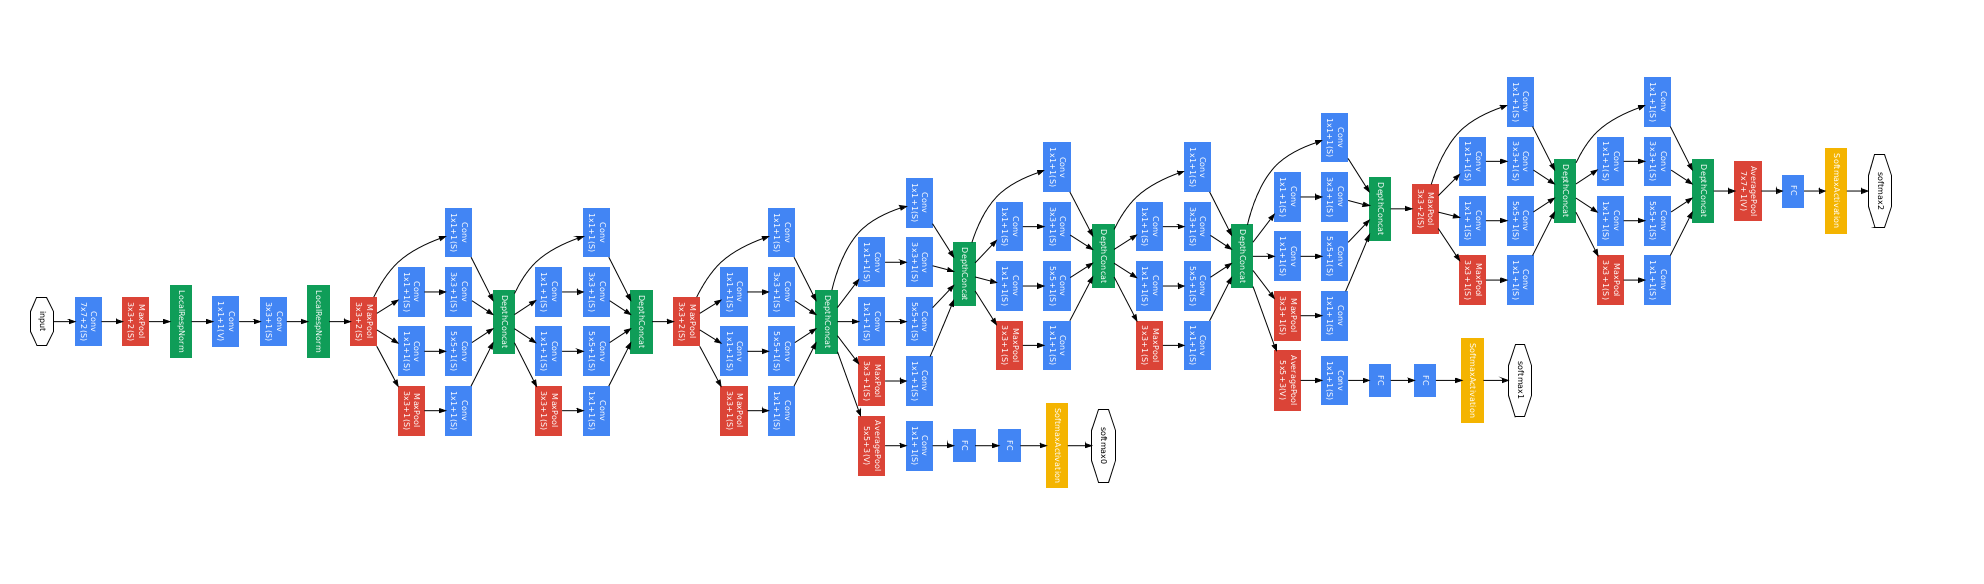

In [76]:
class InceptionModel(nn.Module):
  def __init__(self, in_channels: int = 3, num_classes:int = 10):
    super().__init__()

    # step1
    self.prep = nn.Sequential(
        nn.Conv2d(in_channels, 64, 7, stride=2, padding=3),
        nn.ReLU(),
        nn.MaxPool2d(3, 2, 1),
        nn.BatchNorm2d(64),
        nn.Conv2d(64, 64, 1, padding='same'),
        nn.ReLU(),
        nn.Conv2d(64, 192, 3, padding='same'),
        nn.BatchNorm2d(192),
        nn.MaxPool2d(3, 2, 1)
    )

    # inception 1
    self.inception_3a = InceptionBlock(192, 64, 96, 128, 16, 32, 32)
    self.inception_3b = InceptionBlock(256, 128, 128, 192, 32, 96, 64)

    self.max_pool1 = nn.MaxPool2d(3, 2, 1)

    # inception 2

    self.inception_4a  = InceptionBlock(480, 192, 96, 208, 16, 48, 64)
    self.inception_4b  = InceptionBlock(512, 160, 112, 224, 24, 64, 64)
    self.inception_4c  = InceptionBlock(512, 128, 128, 256, 24, 64, 64)
    self.inception_4d  = InceptionBlock(512, 112, 144, 288, 32, 64, 64)
    self.inception_4e  = InceptionBlock(528, 256, 160, 320, 32, 128, 128)

    self.max_pool2 = nn.MaxPool2d(3, 2, 1)

    # inception 3
    self.inception_5a = InceptionBlock(832, 256, 160, 320, 32, 128, 128)
    self.inception_5b = InceptionBlock(832, 384, 192, 384, 48, 128, 128)

    self.avg_pool1 = nn.AdaptiveAvgPool2d((1, 1))
    self.dropout = nn.Dropout(0.4)
    self.main_output = nn.Linear(1024, num_classes)

  def forward(self, X):
    X = F.relu(self.prep(X))

    X = self.inception_3a(X)
    X = self.inception_3b(X)

    X = self.max_pool1(X)

    X = self.inception_4a(X)
    X = self.inception_4b(X)
    X = self.inception_4c(X)
    X = self.inception_4d(X)
    X = self.inception_4e(X)

    X = self.max_pool2(X)

    X = self.inception_5a(X)
    X = self.inception_5b(X)

    X = self.avg_pool1(X)
    X = torch.flatten(X, 1)
    X = self.dropout(X)
    output = self.main_output(X)

    return output

In [4]:
#!/bin/bash
!curl -L -o chest-xray-pneumonia-balanced-dataset.zip https://www.kaggle.com/api/v1/datasets/download/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1703M  100 1703M    0     0   128M      0  0:00:13  0:00:13 --:--:--  136M


In [5]:
!unzip chest-xray-pneumonia-balanced-dataset.zip

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
  inflating: train/PNEUMONIA/person1059_virus_1758.jpeg  
  inflating: train/PNEUMONIA/person105_virus_193.jpeg  
  inflating: train/PNEUMONIA/person1060_virus_1760.jpeg  
  inflating: train/PNEUMONIA/person1062_bacteria_2996.jpeg  
  inflating: train/PNEUMONIA/person1062_virus_1762.jpeg  
  inflating: train/PNEUMONIA/person1063_virus_1765.jpeg  
  inflating: train/PNEUMONIA/person1065_bacteria_2999.jpeg  
  inflating: train/PNEUMONIA/person1065_virus_1768.jpeg  
  inflating: train/PNEUMONIA/person1066_bacteria_3000.jpeg  
  inflating: train/PNEUMONIA/person1066_virus_1769.jpeg  
  inflating: train/PNEUMONIA/person1067_bacteria_3001.jpeg  
  inflating: train/PNEUMONIA/person1067_virus_1770.jpeg  
  inflating: train/PNEUMONIA/person1069_bacteria_3003.jpeg  
  inflating: train/PNEUMONIA/person106_virus_194.jpeg  
  inflating: train/PNEUMONIA/person1070_virus_1773.jpeg  
  inflating: train/PNEUMONIA/person1071_bacteria_300

In [7]:
!ls

chest-xray-pneumonia-balanced-dataset.zip  sample_data	test  train  val


In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root='/content/train',
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root='/content/val',
    transform=transform
)


In [13]:
class_names = train_dataset.classes

In [25]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [28]:
import numpy as np

In [31]:
next(iter(train_loader))[0].shape

torch.Size([32, 3, 224, 224])

In [77]:
model = InceptionModel(3, num_classes = len(class_names) if len(class_names) > 2 else  1)

In [78]:
if torch.cuda.is_available():
  device='cuda'
elif torch.backends.mps.is_available():
  device='mps'
else:
  device='cpu'

In [79]:
device

'cuda'

In [84]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  for epoch in range(n_epochs):
    total_loss = 0.
    for image, label in train_loader:
      image, label = image.to(device), label.to(device).float().reshape(-1, 1)
      pred = model(image)
      loss = criterion(pred, label)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    mean_loss = total_loss / len(train_loader)
    print(f"Epoch: {epoch+1}/{n_epochs}, Loss: {mean_loss}")

In [85]:
model.train()
model.to(device)


InceptionModel(
  (prep): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (7): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (inception_3a): InceptionBlock(
    (c1): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), padding=same)
    (c2): Sequential(
      (0): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), padding=same)
      (1): ReLU()
      (2): Conv2d(96, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (c3): Sequential(
      (0): Conv2d(192, 16, 

In [86]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
N_EPOCHS = 10

In [ ]:
train(model, optimizer, criterion, train_loader, N_EPOCHS)

Epoch: 1/10, Loss: 0.38301121719846143
